**Adult Income Prediction Machine Learning Project**

In [282]:
# Importing Libraries and Models :-

import pandas as pd

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# ML Models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

**DataSet Overview:**

This section provides the basic information about the dataset.

In [283]:
# Load Dataset :-
df = pd.read_csv("adult.csv")

# Show first 5 rows
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [284]:
# Basic Information
df.info()
print("/n")
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.2 MB
/n


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


**Data Cleaning**

In [288]:
# Replace ? with NaN
df.replace('?', np.nan, inplace=True)

# Remove missing rows
df.dropna(inplace=True)

In [292]:
df.drop(columns=[
    'fnlwgt',
    'race',
    'native.country',
    'education.num'
], inplace=True)

In [293]:
# Checking Missing Values :-

df.isnull().sum()

age               0
workclass         0
education         0
marital.status    0
occupation        0
relationship      0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
income            0
dtype: int64

**Encoding:**
We have to convert the columns that contain text data to numbers.

In [294]:
# Converting Text columns into numbers -:
le = LabelEncoder()

# List the columns that contain text data
columns_to_convert = ['workclass', 'education', 'marital.status', 'occupation',
                      'relationship', 'sex', 'income']

for col in columns_to_convert:
    df[col] = le.fit_transform(df[col])

print("Encoding Done")
df.head()

Encoding Done


,age,workclass,education,marital.status,occupation,relationship,sex,capital.gain,capital.loss,hours.per.week,income
1,82,2,11,6,3,1,0,0,4356,18,0
3,54,2,5,0,6,4,0,0,3900,40,0
4,41,2,15,5,9,3,0,0,3900,40,0
5,34,2,11,0,7,4,0,0,3770,45,0
6,38,2,0,5,0,4,1,0,3770,40,0


**Data Analysis:**
Understand and visualize the dataset distributions and Feature Distribution.

C:\Users\hp\AppData\Local\Temp\ipykernel_2424\1651488041.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='income', data=df, palette=['purple', 'yellow'])


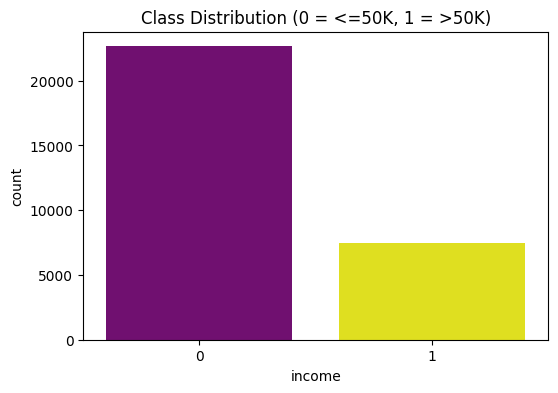

In [289]:
# (a)Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='income', data=df, palette=['purple', 'yellow'])
plt.title("Class Distribution (0 = <=50K, 1 = >50K)")
plt.show()

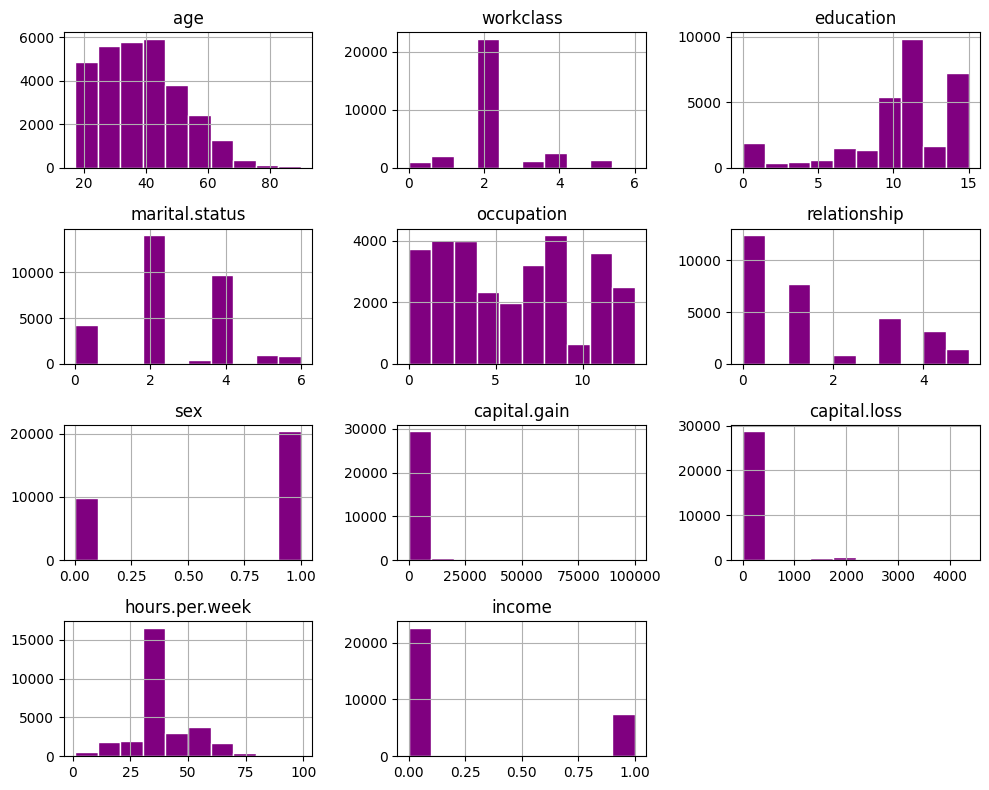

In [295]:
#(b) Feature Distribution
df.hist(figsize=(10, 8), bins=10, color='purple', edgecolor='white', grid=True)

plt.tight_layout()
plt.show()

**Training And Test Split:**
The Dataset is divided into traning (80%) and testing (20%).

In [312]:
# Split Features Target 
X = df.drop('income', axis=1)
y = df['income']

# Spliting Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(" Data Preprocessing is successfully completed")

 Data Preprocessing is successfully completed


**Scaling:**
It is applied to ensure all features contribute equally.

In [313]:
# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling is successfully completed")

Scaling is successfully completed


**Model Training:**
Train multiple Machine Learning Model

In [314]:
# Random Forest

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
preds_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, preds_rf) * 100

In [315]:
# SVM Classifier

svm = SVC(random_state=42)
svm.fit(X_train, y_train)
preds_svm = svm.predict(X_test)

acc_svm = accuracy_score(y_test, preds_svm) * 100

In [316]:
# K-NN Classifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
preds_knn = knn.predict(X_test)

acc_knn = accuracy_score(y_test, preds_knn) * 100



In [317]:
# XGBoost Classifier
xgb = XGBClassifier(random_state=42, eval_metric='mlogloss')
xgb.fit(X_train, y_train)
preds_xgb = xgb.predict(X_test)

# Saving accuracy
acc_xgb = accuracy_score(y_test, preds_xgb) * 100

**Model Evaluation:**
Evaluate models using accuracy, confusion matrix, and classification.

In [318]:
def evaluate_model(name, y_test, y_pred):
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("\n")

# Evaluate all Models

evaluate_model("Random Forest", y_test, preds_rf)
evaluate_model("SVM Classifier", y_test, preds_svm)
evaluate_model("K-NN Classifier", y_test, preds_knn)
evaluate_model("XGBoost Classifier", y_test, preds_xgb)

--- Random Forest ---
Accuracy: 0.8425327366152826
Confusion Matrix:
 [[4171  362]
 [ 588  912]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.92      0.90      4533
           1       0.72      0.61      0.66      1500

    accuracy                           0.84      6033
   macro avg       0.80      0.76      0.78      6033
weighted avg       0.84      0.84      0.84      6033



--- SVM Classifier ---
Accuracy: 0.8165091994032819
Confusion Matrix:
 [[4325  208]
 [ 899  601]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.95      0.89      4533
           1       0.74      0.40      0.52      1500

    accuracy                           0.82      6033
   macro avg       0.79      0.68      0.70      6033
weighted avg       0.81      0.82      0.80      6033



--- K-NN Classifier ---
Accuracy: 0.814685894248301
Confusion Matrix:
 [[4080  453]
 [ 665  835]]
C

**Model Comparison:**
Comparing accuracy for all models.

C:\Users\hp\AppData\Local\Temp\ipykernel_2424\206467536.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=results_df, palette='magma')


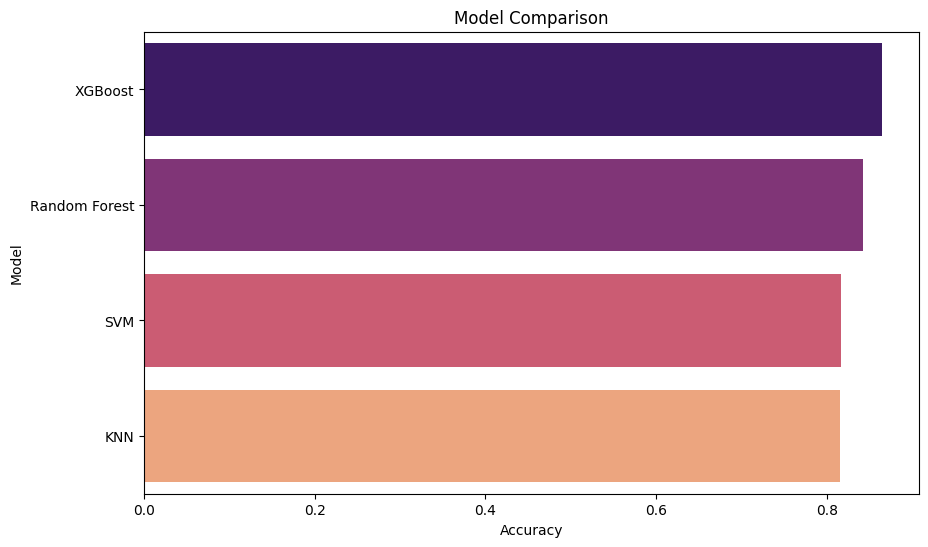

In [319]:
# Model Comparison Visualization
results = {
    "Random Forest": accuracy_score(y_test, preds_rf),
    "SVM": accuracy_score(y_test, preds_svm),
    "KNN": accuracy_score(y_test, preds_knn),
    "XGBoost": accuracy_score(y_test, preds_xgb)
}

results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)


# Bar Plot :-
plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=results_df, palette='magma')
plt.title("Model Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.show()

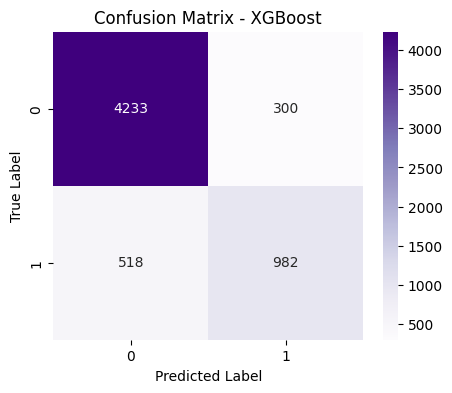

In [320]:
# XGBoost Heatmap
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, preds_xgb), annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

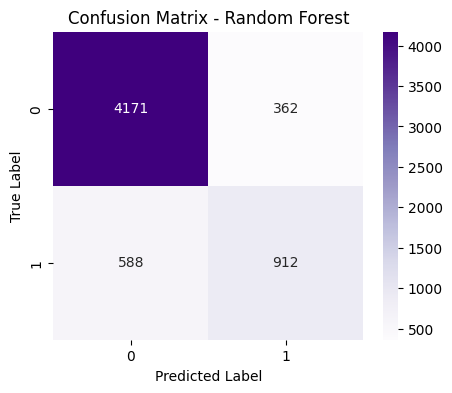

In [327]:
# Random Forest HeatMap
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, preds_rf), annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

**Final Prediction:**
Testing the model with new input data.

In [339]:
# Final Prediction Example(<=50k)

sample_data = {
    'age': [22],
    'workclass': [3],         # Example: Private
    'education': [7],         # Example: Bachelors
    'marital.status': [4],    # Example: Never-married
    'occupation': [1],        # Example: Tech-support
    'relationship': [1],      # Example: Not-in-family  
    'sex': [1],               # Example: Male
    'capital.gain': [0],
    'capital.loss': [0],
    'hours.per.week': [20]
}

sample_df = pd.DataFrame(sample_data)

# Predict using best model Random Forest
final_prediction = rf.predict(sample_df)

# Output Result
if final_prediction[0] == 1:
    print("Income Status: >50K (High Income)")
else:
    print("Income Status: <=50K (Low Income)")

Income Status: <=50K (Low Income)


c:\Users\hp\Desktop\ML_Project\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [ ]:
# Final Prediction Output(>50k)

sample_data = {
    'age': [45],
    'workclass': [4],         # Example: Private
    'education': [12],        # Example: Masters
    'marital.status': [5],    # Example: Married-civ-spouse
    'occupation': [7],        # Example: Exec-managerial
    'relationship': [0],      # Example: Husband
    'sex': [1],               # Example: Male
    'capital.gain': [15000],  # Increased to trigger High Income
    'capital.loss': [0],
    'hours.per.week': [50]
}

sample_df = pd.DataFrame(sample_data)

# Predict using Random Forest
final_prediction = rf.predict(sample_df)

# Output Result
if final_prediction[0] == 1:
    print("Income Status: >50K (High Income)")
else:
    print("Income Status: <=50K (Low Income)")

Income Status: >50K (High Income)


c:\Users\hp\Desktop\ML_Project\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


**Conclusion:**
The primary objective of the project is to utilize the Adult Census Income dataset to predict whether an individual's annual income exceeds $50,000 based on census data.